## Transformer on Toy Data
Generate train/test sets (n=5000 each), train a Transformer sequence model, then evaluate with plots and metrics.

In [1]:
from pathlib import Path
import json

from toy_data.adapters import build_sequence_dataset

# Desired number of supervised next-step targets
n_examples = 5000
raw_train_n = n_examples + 1
raw_test_n = n_examples + 1

train_seed = 42
test_seed = 314

train_seq = build_sequence_dataset(n=raw_train_n, seed=train_seed)
test_seq = build_sequence_dataset(n=raw_test_n, seed=test_seed)

assert len(train_seq['x_seq']) == n_examples
assert len(test_seq['x_seq']) == n_examples

print('Train x_seq length:', len(train_seq['x_seq']))
print('Train y_flip_next length:', len(train_seq['y_flip_next']))
print('Test x_seq length:', len(test_seq['x_seq']))
print('Test y_flip_next length:', len(test_seq['y_flip_next']))

out_dir = Path('toy_data')
out_dir.mkdir(parents=True, exist_ok=True)
with (out_dir / 'transformer_train_n5000.json').open('w', encoding='utf-8') as f:
    json.dump(train_seq, f)
with (out_dir / 'transformer_test_n5000.json').open('w', encoding='utf-8') as f:
    json.dump(test_seq, f)

print('Saved: toy_data/transformer_train_n5000.json')
print('Saved: toy_data/transformer_test_n5000.json')

Train x_seq length: 5000
Train y_flip_next length: 5000
Test x_seq length: 5000
Test y_flip_next length: 5000
Saved: toy_data/transformer_train_n5000.json
Saved: toy_data/transformer_test_n5000.json


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader


class SequenceWindowDataset(Dataset):
    def __init__(self, seq_dict, seq_len=100):
        x_full = seq_dict['x_seq']
        y_full = seq_dict['y_flip_next']

        if len(x_full) != len(y_full):
            raise ValueError('x_seq and y_flip_next must have the same length')
        if len(x_full) < seq_len:
            raise ValueError('Sequence is too short for chosen seq_len')

        X = []
        Y = []
        for i in range(0, len(x_full) - seq_len + 1):
            X.append(x_full[i:i + seq_len])
            Y.append(y_full[i:i + seq_len])

        self.x = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        y_signed = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)
        self.y = (y_signed + 1.0) / 2.0

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


seq_len = 100
batch_size = 64

train_dataset = SequenceWindowDataset(train_seq, seq_len=seq_len)
test_dataset = SequenceWindowDataset(test_seq, seq_len=seq_len)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print('Train windows:', len(train_dataset))
print('Test windows:', len(test_dataset))
print('x shape:', tuple(xb.shape), '| y shape:', tuple(yb.shape))

Train windows: 4901
Test windows: 4901
x shape: (64, 100, 1) | y shape: (64, 100, 1)


In [3]:
import copy
import math
import torch.nn as nn
import torch.optim as optim


class TransformerSequenceModel(nn.Module):
    def __init__(self, input_size=1, d_model=128, nhead=8, num_layers=3, dim_ff=256, dropout=0.1, max_len=512):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, max_len, d_model))
        self.max_len = max_len

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def _causal_mask(self, seq_len, device):
        # Strict causal mask: each position can attend only to itself and the past.
        return torch.triu(torch.full((seq_len, seq_len), float('-inf'), device=device), diagonal=1)

    def forward(self, x):
        # x: [batch, seq_len, input_size]
        _, s, _ = x.shape
        if s > self.max_len:
            raise ValueError(f'seq_len={s} exceeds max_len={self.max_len}')
        h = self.input_proj(x)
        h = h + self.pos_embed[:, :s, :]
        attn_mask = self._causal_mask(s, h.device)
        h = self.encoder(h, mask=attn_mask)
        h = self.norm(h)
        logits = self.head(h)
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerSequenceModel(
    input_size=1,
    d_model=128,
    nhead=8,
    num_layers=3,
    dim_ff=256,
    dropout=0.1,
    max_len=seq_len,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 25
steps_per_epoch = len(train_loader)
total_steps = epochs * steps_per_epoch
warmup_steps = max(1, int(0.1 * total_steps))

def lr_lambda(step_idx):
    if step_idx < warmup_steps:
        return float(step_idx + 1) / float(warmup_steps)
    progress = (step_idx - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

best_test_loss = float('inf')
best_epoch = 0
best_state = None
global_step = 0

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        global_step += 1

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            test_loss += loss.item() * xb.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
        f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f} | lr={current_lr:.6f}'
    )

if best_state is not None:
    model.load_state_dict(best_state)
print(f'Loaded best checkpoint from epoch {best_epoch} with test_loss={best_test_loss:.4f}')

C:\Users\themo\AppData\Local\Temp\ipykernel_21112\4045268338.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Epoch 01 | train_loss=0.6934 | test_loss=0.6764 | test_acc=0.5813 | lr=0.000041
Epoch 02 | train_loss=0.6794 | test_loss=0.6737 | test_acc=0.5841 | lr=0.000081
Epoch 03 | train_loss=0.6780 | test_loss=0.6729 | test_acc=0.5858 | lr=0.000100
Epoch 04 | train_loss=0.6770 | test_loss=0.6716 | test_acc=0.5886 | lr=0.000099
Epoch 05 | train_loss=0.6763 | test_loss=0.6702 | test_acc=0.5915 | lr=0.000097
Epoch 06 | train_loss=0.6754 | test_loss=0.6705 | test_acc=0.5933 | lr=0.000094
Epoch 07 | train_loss=0.6754 | test_loss=0.6694 | test_acc=0.5929 | lr=0.000090
Epoch 08 | train_loss=0.6750 | test_loss=0.6698 | test_acc=0.5925 | lr=0.000086
Epoch 09 | train_loss=0.6748 | test_loss=0.6691 | test_acc=0.5948 | lr=0.000081
Epoch 10 | train_loss=0.6746 | test_loss=0.6689 | test_acc=0.5955 | lr=0.000075
Epoch 11 | train_loss=0.6741 | test_loss=0.6686 | test_acc=0.5968 | lr=0.000069
Epoch 12 | train_loss=0.6738 | test_loss=0.6688 | test_acc=0.5963 | lr=0.000062
Epoch 13 | train_loss=0.6734 | test_loss

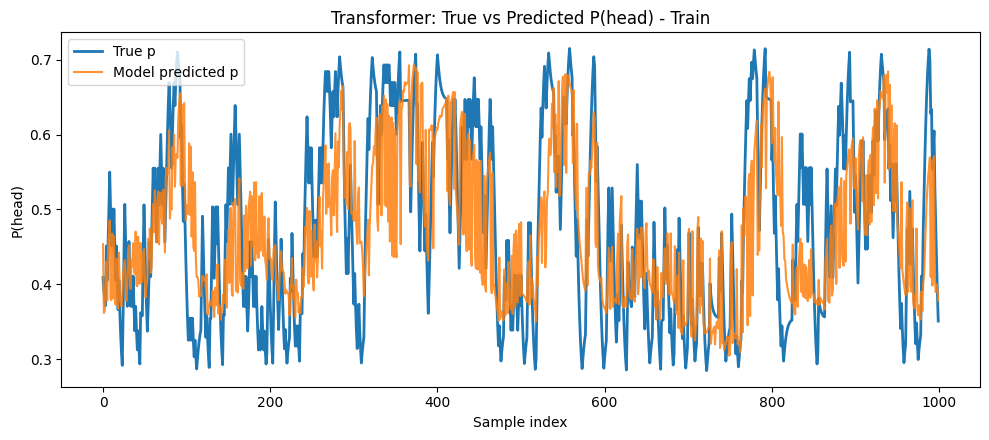

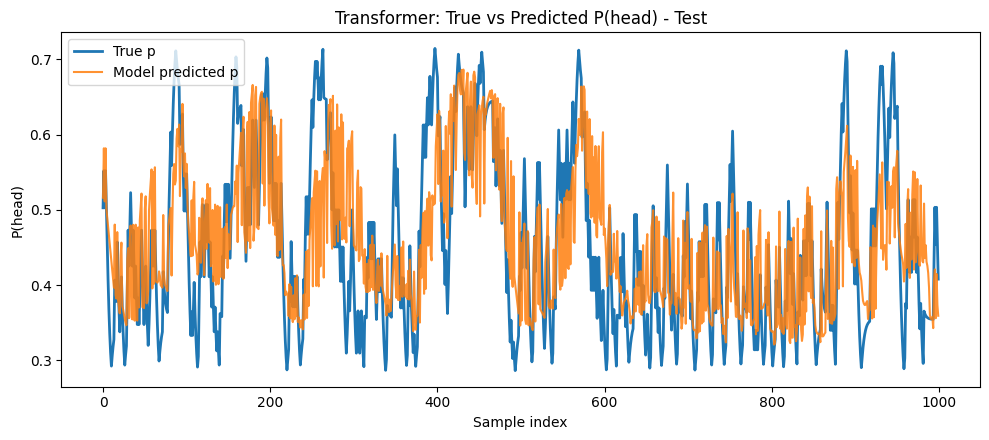

Saved: true_vs_pred_p_transformer_train.png
Saved: true_vs_pred_p_transformer_test.png
Saved: metrics_transformer_comparison.png

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.0692  | 0.0868  | 0.7105 
Test       | 0.0685  | 0.0864  | 0.7207 


In [4]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_torch_sequence,
    plot_true_vs_pred_p_over_samples_torch_sequence,
    save_metrics_comparison_table_png,
)

X_train_windows = train_dataset.x.cpu().tolist()
X_test_windows = test_dataset.x.cpu().tolist()
p_true_train_last = train_seq['y_p_next'][seq_len - 1:]
p_true_test_last = test_seq['y_p_next'][seq_len - 1:]

p_pred_train = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_transformer_train.png',
    title='Transformer: True vs Predicted P(head) - Train',
    show=True,
 )

p_pred_test = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_transformer_test.png',
    title='Transformer: True vs Predicted P(head) - Test',
    show=True,
 )

metrics_train = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

metrics_test = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_transformer_comparison.png',
)

print('Saved: true_vs_pred_p_transformer_train.png')
print('Saved: true_vs_pred_p_transformer_test.png')
print('Saved: metrics_transformer_comparison.png')
print()
print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))

In [1]:
from pathlib import Path
import importlib
import json

import toy_data.adapters as adapters
importlib.reload(adapters)
build_sequence_dataset = adapters.build_sequence_dataset

# Desired number of supervised next-step targets
n_examples = 5000
raw_train_n = n_examples + 1
raw_test_n = n_examples + 1

train_seed = 42
test_seed = 314

train_seq = build_sequence_dataset(n=raw_train_n, seed=train_seed, mode='probabilistic')
test_seq = build_sequence_dataset(n=raw_test_n, seed=test_seed, mode='probabilistic')

assert len(train_seq['x_seq']) == n_examples
assert len(test_seq['x_seq']) == n_examples

print('Train x_seq length:', len(train_seq['x_seq']))
print('Train y_flip_next length:', len(train_seq['y_flip_next']))
print('Test x_seq length:', len(test_seq['x_seq']))
print('Test y_flip_next length:', len(test_seq['y_flip_next']))

out_dir = Path('toy_data')
out_dir.mkdir(parents=True, exist_ok=True)
with (out_dir / 'transformer_train_n5000_noisy.json').open('w', encoding='utf-8') as f:
    json.dump(train_seq, f)
with (out_dir / 'transformer_test_n5000_noisy.json').open('w', encoding='utf-8') as f:
    json.dump(test_seq, f)

print('Saved: toy_data/transformer_train_n5000_noisy.json')
print('Saved: toy_data/transformer_test_n5000_noisy.json')

Train x_seq length: 5000
Train y_flip_next length: 5000
Test x_seq length: 5000
Test y_flip_next length: 5000
Saved: toy_data/transformer_train_n5000_noisy.json
Saved: toy_data/transformer_test_n5000_noisy.json


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader


class SequenceWindowDataset(Dataset):
    def __init__(self, seq_dict, seq_len=100):
        x_full = seq_dict['x_seq']
        y_full = seq_dict['y_flip_next']

        if len(x_full) != len(y_full):
            raise ValueError('x_seq and y_flip_next must have the same length')
        if len(x_full) < seq_len:
            raise ValueError('Sequence is too short for chosen seq_len')

        X = []
        Y = []
        for i in range(0, len(x_full) - seq_len + 1):
            X.append(x_full[i:i + seq_len])
            Y.append(y_full[i:i + seq_len])

        self.x = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        y_signed = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)
        self.y = (y_signed + 1.0) / 2.0

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


seq_len = 100
batch_size = 64

train_dataset = SequenceWindowDataset(train_seq, seq_len=seq_len)
test_dataset = SequenceWindowDataset(test_seq, seq_len=seq_len)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print('Train windows:', len(train_dataset))
print('Test windows:', len(test_dataset))
print('x shape:', tuple(xb.shape), '| y shape:', tuple(yb.shape))

Train windows: 4901
Test windows: 4901
x shape: (64, 100, 1) | y shape: (64, 100, 1)


In [3]:
import copy
import math
import torch.nn as nn
import torch.optim as optim


class TransformerSequenceModel(nn.Module):
    def __init__(self, input_size=1, d_model=128, nhead=8, num_layers=3, dim_ff=256, dropout=0.1, max_len=512):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, max_len, d_model))
        self.max_len = max_len

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def _causal_mask(self, seq_len, device):
        # Strict causal mask: each position can attend only to itself and the past.
        return torch.triu(torch.full((seq_len, seq_len), float('-inf'), device=device), diagonal=1)

    def forward(self, x):
        # x: [batch, seq_len, input_size]
        _, s, _ = x.shape
        if s > self.max_len:
            raise ValueError(f'seq_len={s} exceeds max_len={self.max_len}')
        h = self.input_proj(x)
        h = h + self.pos_embed[:, :s, :]
        attn_mask = self._causal_mask(s, h.device)
        h = self.encoder(h, mask=attn_mask)
        h = self.norm(h)
        logits = self.head(h)
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerSequenceModel(
    input_size=1,
    d_model=128,
    nhead=8,
    num_layers=3,
    dim_ff=256,
    dropout=0.1,
    max_len=seq_len,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 25
steps_per_epoch = len(train_loader)
total_steps = epochs * steps_per_epoch
warmup_steps = max(1, int(0.1 * total_steps))

def lr_lambda(step_idx):
    if step_idx < warmup_steps:
        return float(step_idx + 1) / float(warmup_steps)
    progress = (step_idx - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

best_test_loss = float('inf')
best_epoch = 0
best_state = None
global_step = 0

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        global_step += 1

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            test_loss += loss.item() * xb.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
        f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f} | lr={current_lr:.6f}'
    )

if best_state is not None:
    model.load_state_dict(best_state)
print(f'Loaded best checkpoint from epoch {best_epoch} with test_loss={best_test_loss:.4f}')

C:\Users\themo\AppData\Local\Temp\ipykernel_10552\4045268338.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Epoch 01 | train_loss=0.6880 | test_loss=0.6863 | test_acc=0.5509 | lr=0.000041
Epoch 02 | train_loss=0.6808 | test_loss=0.6861 | test_acc=0.5546 | lr=0.000081
Epoch 03 | train_loss=0.6798 | test_loss=0.6850 | test_acc=0.5549 | lr=0.000100
Epoch 04 | train_loss=0.6788 | test_loss=0.6856 | test_acc=0.5556 | lr=0.000099
Epoch 05 | train_loss=0.6782 | test_loss=0.6847 | test_acc=0.5571 | lr=0.000097
Epoch 06 | train_loss=0.6779 | test_loss=0.6838 | test_acc=0.5586 | lr=0.000094
Epoch 07 | train_loss=0.6777 | test_loss=0.6845 | test_acc=0.5575 | lr=0.000090
Epoch 08 | train_loss=0.6774 | test_loss=0.6840 | test_acc=0.5575 | lr=0.000086
Epoch 09 | train_loss=0.6772 | test_loss=0.6841 | test_acc=0.5591 | lr=0.000081
Epoch 10 | train_loss=0.6772 | test_loss=0.6841 | test_acc=0.5582 | lr=0.000075
Epoch 11 | train_loss=0.6770 | test_loss=0.6837 | test_acc=0.5598 | lr=0.000069
Epoch 12 | train_loss=0.6767 | test_loss=0.6836 | test_acc=0.5599 | lr=0.000062
Epoch 13 | train_loss=0.6765 | test_loss

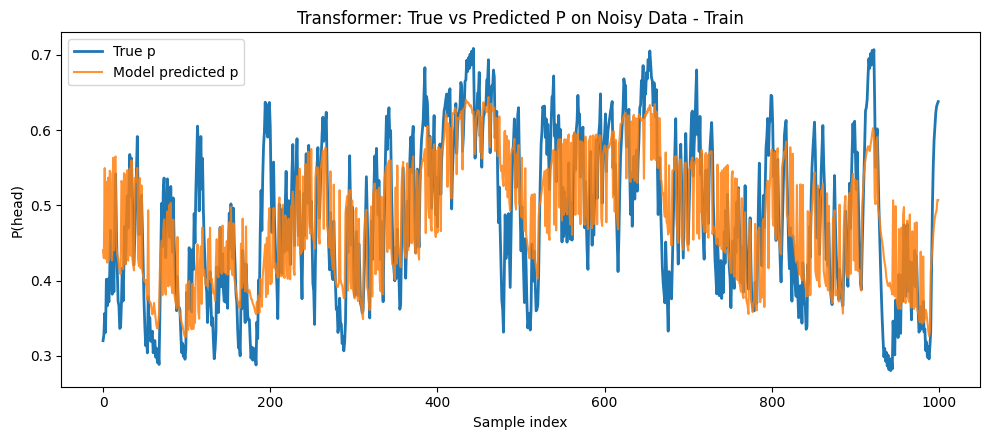

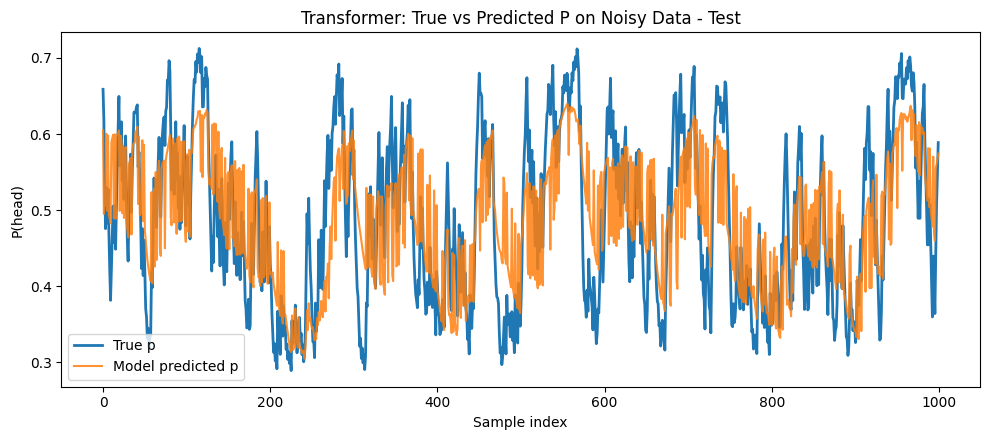

Saved: true_vs_pred_p_transformer_train_noisy.png
Saved: true_vs_pred_p_transformer_test_noisy.png
Saved: metrics_transformer_comparison_noisy.png

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.0531  | 0.0658  | 0.7834 
Test       | 0.0524  | 0.0648  | 0.7725 


In [4]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_torch_sequence,
    plot_true_vs_pred_p_over_samples_torch_sequence,
    save_metrics_comparison_table_png,
)

X_train_windows = train_dataset.x.cpu().tolist()
X_test_windows = test_dataset.x.cpu().tolist()
p_true_train_last = train_seq['y_p_next'][seq_len - 1:]
p_true_test_last = test_seq['y_p_next'][seq_len - 1:]

p_pred_train = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_transformer_train_noisy.png',
    title='Transformer: True vs Predicted P on Noisy Data - Train',
    show=True,
 )

p_pred_test = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_transformer_test_noisy.png',
    title='Transformer: True vs Predicted P on Noisy Data - Test',
    show=True,
 )

metrics_train = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

metrics_test = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_transformer_comparison_noisy.png',
)

print('Saved: true_vs_pred_p_transformer_train_noisy.png')
print('Saved: true_vs_pred_p_transformer_test_noisy.png')
print('Saved: metrics_transformer_comparison_noisy.png')
print()
print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))